## Setup

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import sys
import tensorflow as tf
from tensorflow.keras import layers, models
import warnings

import matplotlib.pyplot as plt

import numpy as np
import cv2

In [3]:
sys.path.insert(0, "../src/")
warnings.filterwarnings("ignore")

In [4]:
from image_preprocessing import load_dataset

## Datasets

In [5]:
dataset_dirs = [directory for directory in os.listdir("../dataset/") if not directory.endswith('.py') and not directory.endswith('.json')]
dataset_dirs

['Garbage Classification Dataset',
 'Garbage Dataset',
 'New Trash Classfication Dataset',
 'Waste Classfication Dataset']

In [6]:
DATASET_PATH = '../dataset/Waste Classfication Dataset/balanced_waste_images'

In [7]:
train, val, classes = load_dataset(DATASET_PATH)

Found 6782 files belonging to 17 classes.
Using 5426 files for training.


2026-04-22 17:12:15.250740: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Found 6782 files belonging to 17 classes.
Using 1356 files for validation.


## MobileNet Model

In [8]:
def create_model(num_classes):

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(64, 64, 3),
        alpha=0.35,
        include_top=False,
        weights='imagenet')
    base_model.trainable = False
    model = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')])
    return model

In [9]:
model = create_model(len(classes))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_0.35_224 (Func  (None, 2, 2, 1280)        410208    
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 32)                40992     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 17)                561       
                                                                 
Total params: 451761 (1.72 MB)
Trainable params: 41553 (

## Model Training

In [10]:
EPOCHS = 15

os.makedirs('models', exist_ok=True)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/model_mobilenet.h5", monitor="val_accuracy", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

history = model.fit(train, validation_data=val, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/15
169/170 [============================>.] - ETA: 0s - loss: 2.2090 - accuracy: 0.3128
Epoch 1: val_accuracy improved from -inf to 0.51991, saving model to models/model_mobilenet.h5
170/170 [==============================] - 17s 73ms/step - loss: 2.2058 - accuracy: 0.3137 - val_loss: 1.5170 - val_accuracy: 0.5199
Epoch 2/15
170/170 [==============================] - ETA: 0s - loss: 1.5144 - accuracy: 0.5181
Epoch 2: val_accuracy improved from 0.51991 to 0.61283, saving model to models/model_mobilenet.h5
170/170 [==============================] - 11s 67ms/step - loss: 1.5144 - accuracy: 0.5181 - val_loss: 1.2660 - val_accuracy: 0.6128
Epoch 3/15
169/170 [============================>.] - ETA: 0s - loss: 1.2955 - accuracy: 0.5773
Epoch 3: val_accuracy improved from 0.61283 to 0.63569, saving model to models/model_mobilenet.h5
170/170 [==============================] - 11s 64ms/step - loss: 1.2946 - accuracy: 0.5772 - val_loss: 1.1624 - val_accuracy: 0.6357
Epoch 4/15
170/170 [==

## Evaluation

In [11]:
test_loss, test_accuracy = model.evaluate(val)
print(f"\nValidation Loss: {test_loss:.4f}")
print(f"Validation Accuracy: {test_accuracy:.4f}")

43/43 [==============================] - 2s 55ms/step - loss: 0.9998 - accuracy: 0.6903

Validation Loss: 0.9998
Validation Accuracy: 0.6903


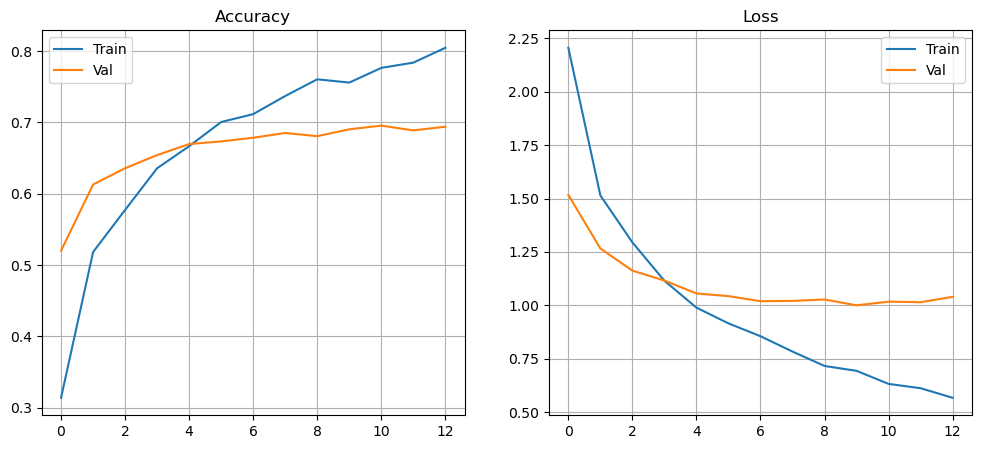

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid()

plt.show()

## Saving the model

In [15]:
model.save("models/mobile_net_model_v1.keras")
print(f"Model Saved")

Model Saved


1/1 [==============================] - 1s 748ms/step
Prediction: organic
Confidence: 0.98739374


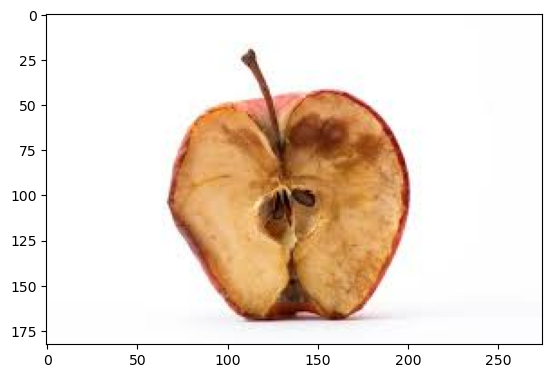

In [35]:
model = tf.keras.models.load_model("models/mobile_net_model_v1.keras")
IMG_SIZE = 64

# Load test image
img = cv2.imread("test-images/images.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

# Preprocess (MUST match training)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_norm = img_resized / 255.0
img_input = np.expand_dims(img_norm, axis=0)

# Predict
pred = model.predict(img_input)

pred_idx = np.argmax(pred)
confidence = pred[0][pred_idx]

print("Prediction:", classes[pred_idx])
print("Confidence:", confidence)

## Converting to TFLite

In [29]:
model = tf.keras.models.load_model("models/mobile_net_model_v1.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("models/mobile_net_model_v1.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved basic TFLite model")

INFO:tensorflow:Assets written to: /tmp/tmpuntptigp/assets


INFO:tensorflow:Assets written to: /tmp/tmpuntptigp/assets


Saved basic TFLite model


## Size Comparison

In [30]:
import os

keras_path = "models/mobile_net_model_v1.keras"
tflite_path = "models/mobile_net_model_v1.tflite"

def get_size(path):
    size_bytes = os.path.getsize(path)
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024
    return size_bytes, size_kb, size_mb

# Get sizes
k_bytes, k_kb, k_mb = get_size(keras_path)
t_bytes, t_kb, t_mb = get_size(tflite_path)

print("Keras Model:")
print(f"{k_bytes} bytes | {k_kb:.2f} KB | {k_mb:.2f} MB")

print("TFLite Model:")
print(f"{t_bytes} bytes | {t_kb:.2f} KB | {t_mb:.2f} MB")

reduction = ((k_mb - t_mb) / k_mb) * 100
print(f"Size Reduction: {reduction:.2f}%")

Keras Model:
2669547 bytes | 2606.98 KB | 2.55 MB
TFLite Model:
1761984 bytes | 1720.69 KB | 1.68 MB
Size Reduction: 34.00%


## Quantization

In [32]:
model = tf.keras.models.load_model("models/mobile_net_model_v1.keras")

def representative_data_gen():
    for images, _ in train.take(100):
        yield [images]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
tflite_quant = converter.convert()

with open("models/model_openmv_v1.tflite", "wb") as f:
    f.write(tflite_quant)

print("Quantized model saved")

INFO:tensorflow:Assets written to: /tmp/tmpioqv3bd1/assets


INFO:tensorflow:Assets written to: /tmp/tmpioqv3bd1/assets


Quantized model saved


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [33]:
import os

size = os.path.getsize("models/model_openmv_v1.tflite") / (1024 * 1024)
print(f"Quantized model size: {size:.2f} MB")

Quantized model size: 0.63 MB


In [34]:
interpreter = tf.lite.Interpreter(model_path="models/model_openmv_v1.tflite")
interpreter.allocate_tensors()
interpreter.get_input_details()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


[{'name': 'serving_default_input_2:0',
  'index': 0,
  'shape': array([ 1, 64, 64,  3], dtype=int32),
  'shape_signature': array([-1, 64, 64,  3], dtype=int32),
  'dtype': numpy.uint8,
  'quantization': (0.003921568859368563, 0),
  'quantization_parameters': {'scales': array([0.00392157], dtype=float32),
   'zero_points': array([0], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]